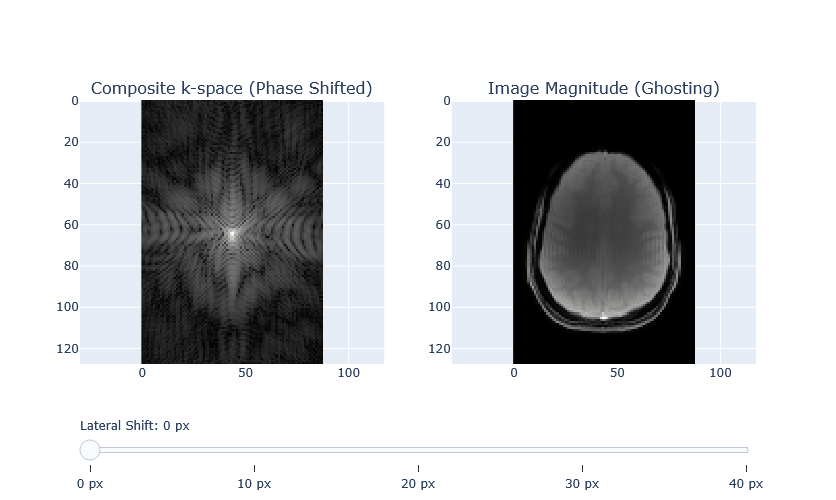

In [4]:
#| label: fig5

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load original data
k_space_orig = np.load('kspace_combined.npy')
img_orig = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k_space_orig)))
rows, cols = k_space_orig.shape
split_line = (rows // 2) + 5 

# Subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=("Composite k-space (Phase Shifted)", "Image Magnitude (Ghosting)"))
frames, steps = [], []
shifts = [0, 10, 20, 30, 40]

for i, shift in enumerate(shifts):
    # Simulate lateral shift in image space
    img_shifted = np.roll(img_orig, shift=shift, axis=1)
    k_space_shifted = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img_shifted)))
    
    # Splice k-spaces
    k_space_comp = np.zeros_like(k_space_orig, dtype=complex)
    k_space_comp[:split_line, :] = k_space_orig[:split_line, :]
    k_space_comp[split_line:, :] = k_space_shifted[split_line:, :]
    
    # Reconstruct
    img_sim = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k_space_comp)))
    img_mag = np.abs(img_sim)
    k_log = np.log(np.abs(k_space_comp) + 1e-5)
    
    if i == 0:
        fig.add_trace(go.Heatmap(z=k_log, colorscale='gray', showscale=False), row=1, col=1)
        fig.add_trace(go.Heatmap(z=img_mag, colorscale='gray', showscale=False), row=1, col=2)
        
    frames.append(go.Frame(data=[go.Heatmap(z=k_log), go.Heatmap(z=img_mag)], name=str(shift)))
    steps.append(dict(
        method="animate",
        args=[[str(shift)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}],
        label=f"{shift} px"
    ))

fig.frames = frames
fig.update_layout(sliders=[dict(active=0, currentvalue={"prefix": "Lateral Shift: "}, pad={"t": 50}, steps=steps)], height=500)
fig.update_yaxes(scaleanchor="x", autorange="reversed")
fig.update_yaxes(scaleanchor="x2", autorange="reversed", row=1, col=2)
fig